In [106]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
#from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [109]:
def index_containing_substring(the_list, substring):
    try:
        return [s for i, s in enumerate(the_list) if substring in s][0]
    except IndexError:
        return False

In [110]:
list1 = ['apple', 'banana', 'asfapearfad']
substring = "ana"
output = index_containing_substring(list1, substring)
print(output)

banana


In [113]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/Cropped_data-20240527T214451Z-001.zip

import os.path


data_path = "/workspaces/work/Dataset/Cropped_data"
devices = os.listdir(data_path)
target_dir = "/workspaces/work/Dataset/Cropped_data/Device_1/Cihaz_1"
crop_len = float('inf')

def extract_IQ_samples_from_txt_file(path_to_txt, crop_len):

    I_samples = []
    Q_samples = []

    files = os.listdir(target_dir)
    Real = [file for file in files if 'I' in file]
    Imaginary = [file for file in files if 'Q' in file]

    for file in Real:
        file_number = file.split('.')[0][1:]
        I_path_temp = index_containing_substring(Real, file_number)
        Q_temp_path = index_containing_substring(Imaginary, file_number)
        if Q_temp_path != False:
            I_path_temp = os.path.join(target_dir, I_path_temp)
            Q_temp_path = os.path.join(target_dir, Q_temp_path)
        
            I_sample = np.loadtxt(I_path_temp)
            Q_sample = np.loadtxt(Q_temp_path)

            I_len = len(I_sample)
            Q_len = len(Q_sample)

            if I_len < crop_len:
                crop_len = I_len
            if Q_len < crop_len:
                crop_len = Q_len
                
            I_samples.append(I_sample)
            Q_samples.append(Q_sample)

    return I_samples, Q_samples, crop_len


In [114]:
device1_path = "/workspaces/work/Dataset/Cropped_data/Device_1/Cihaz_1"
device2_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_2"
device3_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_3"
device4_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_4"

I_samples_1, Q_samples_1, crop_len1 = extract_IQ_samples_from_txt_file(device1_path, crop_len)
I_samples_2, Q_samples_2, crop_len2 = extract_IQ_samples_from_txt_file(device2_path, crop_len1)
I_samples_3, Q_samples_3, crop_len3 = extract_IQ_samples_from_txt_file(device3_path, crop_len2)
I_samples_4, Q_samples_4, crop_len4 = extract_IQ_samples_from_txt_file(device4_path, crop_len3)

In [115]:
assert(len(I_samples_1) == len(Q_samples_1)), "lengths not equal for device 1"
assert(len(I_samples_2) == len(Q_samples_2)), "lengths not equal for device 2"
assert(len(I_samples_3) == len(Q_samples_3)), "lengths not equal for device 3"
assert(len(I_samples_4) == len(Q_samples_4)), "lengths not equal for device 4"

In [116]:
crop_len = 1000
I_samples_1, Q_samples_1 = [I_samples_1[i][:crop_len] for i in range(len(I_samples_1))], [Q_samples_1[i][:crop_len] for i in range(len(Q_samples_1))]
I_samples_2, Q_samples_2 = [I_samples_2[i][:crop_len] for i in range(len(I_samples_2))], [Q_samples_2[i][:crop_len] for i in range(len(Q_samples_2))]
I_samples_3, Q_samples_3 = [I_samples_3[i][:crop_len] for i in range(len(I_samples_3))], [Q_samples_3[i][:crop_len] for i in range(len(Q_samples_3))]
I_samples_4, Q_samples_4 = [I_samples_4[i][:crop_len] for i in range(len(I_samples_4))], [Q_samples_4[i][:crop_len] for i in range(len(Q_samples_4))]

In [117]:
assert(len(I_samples_1) == len(Q_samples_1) == len(I_samples_2) == len(Q_samples_2) == len(I_samples_3) == len(Q_samples_3) == len(I_samples_4) == len(Q_samples_4)), "lengths not equal for all device 1"
I_samples_1, Q_samples_1 = np.array(I_samples_1), np.array(Q_samples_1)
I_samples_2, Q_samples_2 = np.array(I_samples_2), np.array(Q_samples_2)
I_samples_3, Q_samples_3 = np.array(I_samples_3), np.array(Q_samples_3)
I_samples_4, Q_samples_4 = np.array(I_samples_4), np.array(Q_samples_4)


In [118]:
samples_from_each_device = I_samples_1.shape[0]
real_part = np.vstack((I_samples_1, I_samples_2, I_samples_3, I_samples_4))
imaginary_part = np.vstack((Q_samples_1, Q_samples_2, Q_samples_3, Q_samples_4))


In [119]:
labels1 = np.array([0 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels2 = np.array([1 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels3 = np.array([2 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels4 = np.array([3 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels = np.vstack((labels1, labels2, labels3, labels4))
print(labels.shape, real_part.shape)

(3372, 1) (3372, 1000)


In [121]:
data = real_part + 1j * imaginary_part

In [125]:
data.shape

(3372, 1000)

In [127]:

def normalization(data):
    normalized_results = []
    count = 0

    for signal in data:
            # Min-max normalizasyonu
        min_val = np.min(signal)
        max_val = np.max(signal)
        normalized_result = (signal - min_val) / (max_val - min_val)

        count = count +1
        print(count)
        normalized_results.append(normalized_result)

    return np.array(normalized_results)
  
    


In [128]:
normalized_data=normalization(data)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [150]:
normalized_data.shape


(3372, 1000)

In [151]:
data=normalized_data

In [171]:
import numpy as np
from sklearn.preprocessing import normalize, power_transform, robust_scale, scale

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(data)
imaginary_part = np.imag(data)


# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)
# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((data.shape[0],data.shape[1], 2))


In [172]:
data_real_values.shape

(3372, 1000, 2)

In [173]:
print(data_real_values.shape)
print(labels.shape)
print(np.unique(labels))

(3372, 1000, 2)
(3372, 1)
[0 1 2 3]


In [174]:
data_real_values.shape


(3372, 1000, 2)

In [175]:
#SOME PREPROCESSING
#data_real_values = np.real(data).reshape(data.shape[0], 1, data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, labels, test_size=0.3, shuffle=True)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [176]:
print(data_real_values.shape)
print(data_real_values_train.shape)
print(data_real_values_test.shape)



(3372, 1000, 2)
(2360, 1000, 2)
(1012, 1000, 2)


In [178]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Dropout

# If your data is complex, you can convert it to real numbers:
# Method 1: Use the magnitude (absolute value) of complex numbers
data_real_values_train = np.abs(data_real_values_train)
data_real_values_test = np.abs(data_real_values_test)



# Ensure data type is float32
data_real_values_train = data_real_values_train.astype(np.float32)
data_real_values_test = data_real_values_test.astype(np.float32)
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1000, 2)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(512, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(4, activation='softmax'))

model_to_train = cnn_model

# loss1 = keras.losses.CategoricalFocalCrossentropy()
# loss2 = keras.losses.CategoricalCrossentropy()

loss1 = keras.losses.SparseCategoricalCrossentropy()
#loss2 = keras.losses.BinaryCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.1) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

train_history = model_to_train.fit(data_real_values_train, label_train, 
                                   validation_data = (data_real_values_test, label_test),
                                   epochs=15, batch_size=64)





Epoch 1/15


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.2043 - loss: 1050540.1250 - val_accuracy: 0.2490 - val_loss: 1.4074
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.2695 - loss: 1.3914 - val_accuracy: 0.2520 - val_loss: 1.3881
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.2517 - loss: 1.3910 - val_accuracy: 0.2411 - val_loss: 1.3869
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.2604 - loss: 1.3893 - val_accuracy: 0.2530 - val_loss: 1.3917
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.2381 - loss: 1.3952 - val_accuracy: 0.2648 - val_loss: 1.3870
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - accuracy: 0.2176 - loss: 1.3933 - val_accuracy: 0.2648 - val_loss: 1.3956
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.2304 - loss: 1.3944 - val_accuracy: 0.2648 - val_loss: 1.3879
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.2546 - loss: 1.3915 - val_accuracy: 0.2530

In [168]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout

# If your data is complex, you can convert it to real numbers:
# Method 1: Use the magnitude (absolute value) of complex numbers
#data_real_values_train = np.abs(data_real_values_train)
#data_real_values_test = np.abs(data_real_values_test)

# Method 2: Use both real and imaginary parts as separate features
data_real_values_train = np.stack((data_real_values_train.real, data_real_values_train.imag), axis=-1)
data_real_values_test = np.stack((data_real_values_test.real, data_real_values_test.imag), axis=-1)

# Ensure data type is float32
data_real_values_train = data_real_values_train.astype(np.float32)
data_real_values_test = data_real_values_test.astype(np.float32)

# Define the CNN model
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(data_real_values_train.shape[1], data_real_values_train.shape[2])))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(4, activation='softmax'))

model_to_train = cnn_model

# Define the loss and optimizer
loss1 = tf.keras.losses.CategoricalCrossentropy()
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.1)

# Compile the model
model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

# Train the model
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                   validation_data=(data_real_values_test, label_test),
                                   epochs=15, batch_size=64)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 2
'y' sizes: 2360


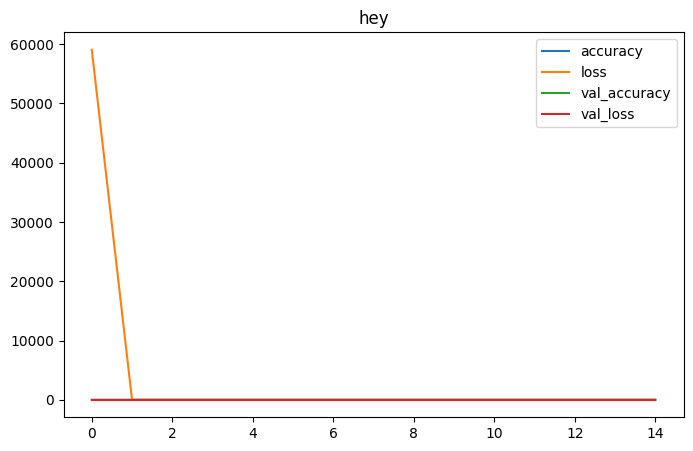

In [94]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'hey')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [95]:
# data_real_values_test, label_train, label_testa
all_labels = np.unique(binary_labels)
predictions = model_to_train.predict(data_real_values_test)
predictions = np.argmax(predictions, axis=1).reshape(predictions.shape[0], 1)
confusion_matrix = metrics.confusion_matrix(label_test, predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = all_labels)
cm_display.plot()
plt.show()
precision_recall_fscore_support(label_test, predictions, average='macro')



ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 1000, 2, 2), dtype=float32). Expected shape (None, 1000, 2), but input has incompatible shape (32, 1000, 2, 2)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 1000, 2, 2), dtype=float32)
  • training=False
  • mask=None

# SAVING MODEL AND LOADING MODEL

In [5]:
path_to_model = './trained_models/my_model.h5'

#model_to_train.save(path_to_model)

loaded_model = tf.keras.models.load_model(path_to_model)

#loaded_model.summary()

In [6]:
file_path = "/workspaces/work/dataset_training_aug.h5"   
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0, 30000, dtype = int)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
TEST_data, TEST_label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

                                                

Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [9]:
#SOME PREPROCESSING
TEST_data_real_values = np.real(TEST_data).reshape(TEST_data.shape[0], 1, TEST_data.shape[1])


938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


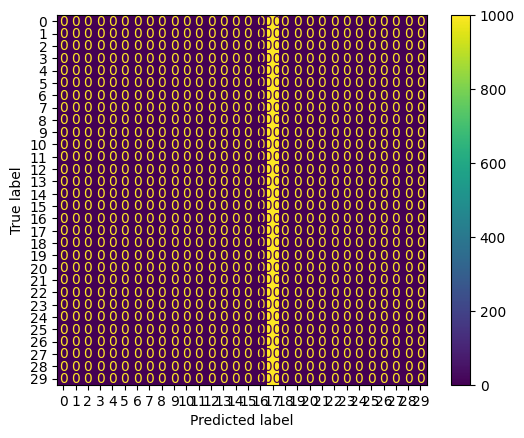

/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.0011111111111111111, 0.03333333333333333, 0.002150537634408602, None)

In [13]:
# loss, acc = loaded_model.evaluate(TEST_data, TEST_label)

All_labels = np.unique(TEST_label)
TEST_predictions = loaded_model.predict(TEST_data_real_values)

TEST_predictions = np.argmax(TEST_predictions, axis=1).reshape(TEST_predictions.shape[0], 1)

TEST_confusion_matrix = metrics.confusion_matrix(TEST_label, TEST_predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = TEST_confusion_matrix, display_labels = All_labels)
cm_display.plot()
plt.show()

precision_recall_fscore_support(TEST_label, TEST_predictions, average='macro')

# SPECTROGRAM 

In [2]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/dataset_training_aug.h5"

In [3]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0, 5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, labels = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [4]:
data_real_values = np.real(data).reshape(data.shape[0], 1, data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
# data_real_values.shape
# data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, binary_labels, test_size=0.3, shuffle=True)

In [5]:
data_real_values[0].shape

(1, 8192)

In [45]:
# ROOT MEAN SQUARED FOR NORMALISATION
def calculate_rms(array):
    squared_values = np.square(array)  # Square each element of the array
    mean_squared = (np.sum(np.sum(squared_values)))/array.shape[0] # Calculate the mean of the squared values
    rms = np.sqrt(mean_squared)
    norm_array = array/rms
    return norm_array


In [48]:
for i in range(data_real_values.shape[0]):
    data_real_values[i] = calculate_rms(data_real_values[i])

In [5]:
def train_feature_extractor(
    file_path = 
    #'/workspaces/work/dataset_training_no_aug.h5'
    "/workspaces/work/dataset_training_aug.h5", 
    dev_range = np.arange(0,30, dtype = int), 
    pkt_range = np.arange(0,1000, dtype = int), 
    snr_range = np.arange(20,80)):

                            
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
    #######################################################3
    # data = np.real(data).reshape(data.shape[0], 1, data.shape[1])
    # for i in range(data.shape[0]):
    #     data[i] = calculate_rms(data[i])
    ##########################################################
        
    # Add additive Gaussian noise to the IQ samples.
    data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    return data, label
    

In [6]:
spectrogram_data, spectrogram_label = train_feature_extractor()
total_samples, height, width, _ = spectrogram_data.shape
spectrogram_data_reshaped = spectrogram_data.reshape(total_samples, height, width)


Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [59]:
print(spectrogram_data.shape)

(30000, 102, 62, 1)


In [22]:
total_samples, height, width, _ = spectrogram_data.shape
spectrogram_data_reshaped = spectrogram_data.reshape(total_samples, height*width)
print(spectrogram_data_reshaped.shape)


(30000, 6324)


In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler

#scaling=StandardScaler()
r_scaling =RobustScaler()

r_scaling.fit(spectrogram_data_reshaped)

# Use fit and transform method 
Scaled_data= r_scaling.transform(spectrogram_data_reshaped)

# Set the n_components=3
principal=PCA(n_components=50)
principal.fit(Scaled_data)
pca_spectrogram_data =principal.transform(Scaled_data)
total_samples, width = pca_spectrogram_data.shape
pca_spectrogram_data = pca_spectrogram_data.reshape(total_samples, 1, width)
    
# # Check the dimensions of data after PCA
print("Previous shape one sample is", spectrogram_data_reshaped[:, 0].shape)
print("New shape of one one sample is", pca_spectrogram_data[:,0].shape)

Previous shape one sample is (30000,)
New shape of one one sample is (30000, 50)


In [ ]:
# # VISUALISE ORIGINAL SAMPLE
# test_sample = spectrogram_data_reshaped[0]
# plt.figure(figsize=(6, 3.2))
# plt.imshow(test_sample, cmap='viridis', interpolation='nearest')
# plt.colorbar()
# plt.title('ColorMap')
# plt.show()

Text(0, 0.5, 'pc2')

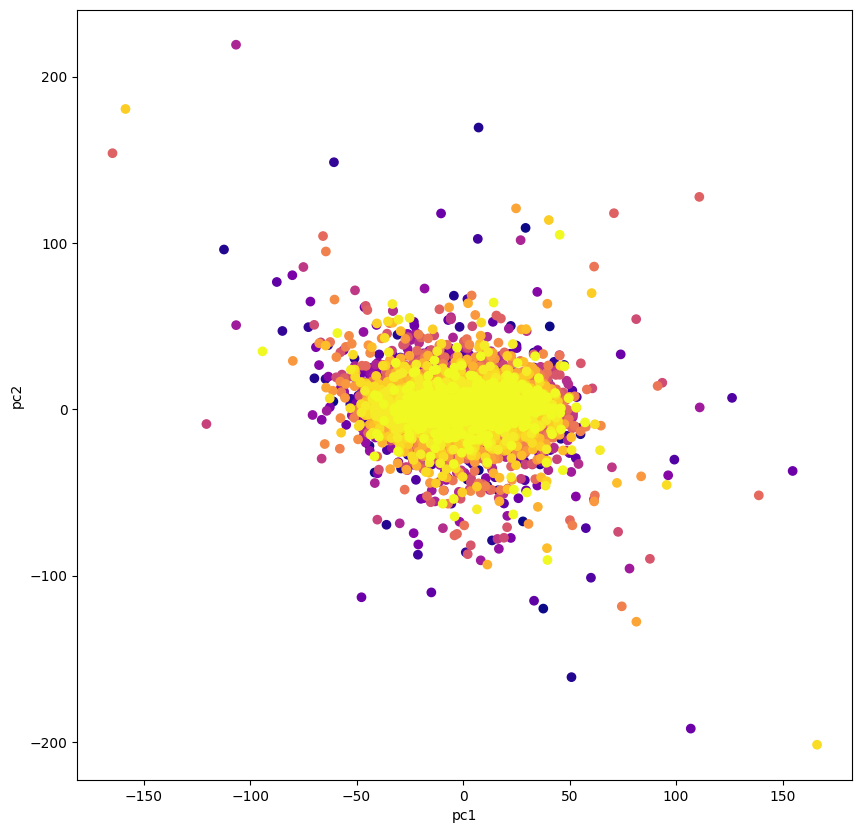

In [30]:
plt.figure(figsize=(10,10))
plt.scatter(pca_spectrogram_data[:,0], pca_spectrogram_data[:,1], c=spectrogram_label, cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

In [47]:
pca_spectrogram_data[0].shape

(1, 50)

In [35]:
binary_spectrogram_labels = np.where(spectrogram_label <=19, 0, 1)

# data_real_values_train2, data_real_values_test2, label_train2, label_test2 = train_test_split(spectrogram_data, 
#                                                                     label, 
#                                                                     test_size=0.2, 
#                                                                     shuffle= True)

In [12]:
spectrogram_data.shape
np.unique(binary_spectrogram_labels)

array([0, 1])

In [61]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# cnn_model2 = Sequential()
# cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(height, width, 1)))
# cnn_model2.add(MaxPooling2D(pool_size=2, padding='same'))
# #cnn_model2.add(Dropout(0.2))
# cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
# cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
# cnn_model2.add(Flatten())
# cnn_model2.add(Dense(64, activation='relu'))
# cnn_model2.add(Dense(1, activation='sigmoid'))

#cnn_model2.summary()

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, width)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(512, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# cnn_model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

model_to_train = cnn_model

loss1 = keras.losses.BinaryFocalCrossentropy()
loss2 = keras.losses.BinaryCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.0001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.01) # https://keras.io/api/optimizers/rmsprop/
optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

train_history = model_to_train.fit(pca_spectrogram_data, binary_spectrogram_labels, 
                                   epochs=10, batch_size=20)

Epoch 1/10


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 879us/step - accuracy: 0.6650 - loss: 0.1667
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - accuracy: 0.6654 - loss: 0.1610
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.6598 - loss: 0.1607
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.6655 - loss: 0.1591
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 874us/step - accuracy: 0.6713 - loss: 0.1578
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.6736 - loss: 0.1574
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - accuracy: 0.6765 - loss: 0.1566
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step - accuracy: 0.6813 - loss: 0.1557
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - accuracy: 0.6839 - loss: 0.1551
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 893us/step - accuracy: 0.6841 - loss: 0.1549


468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step


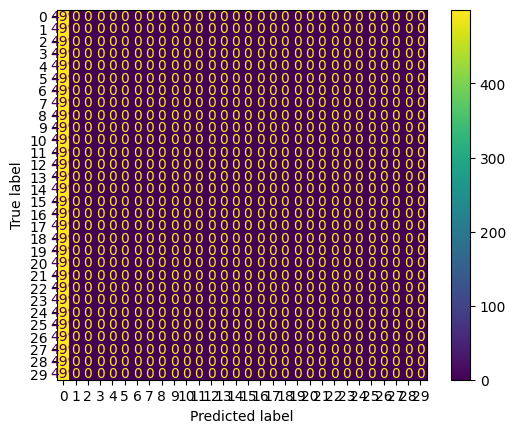

/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.0011111111111111111, 0.03333333333333333, 0.002150537634408602, None)

In [48]:
# data_real_values_test, label_train, label_testa
all_labels = np.unique(label)
predictions = model_to_train.predict(spectrogram_data_reshaped)
predictions = np.argmax(predictions, axis=1).reshape(predictions.shape[0], 1)
confusion_matrix = metrics.confusion_matrix(spectrogram_label, predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = all_labels)
cm_display.plot()
plt.show()
precision_recall_fscore_support(spectrogram_label, predictions, average='macro')



In [ ]:
file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,30000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
TEST_data, TEST_label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

                                                
predictions = model_to_train.predict(TEST_data)
